# 1. Import Libraries

In [1]:
# ==========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset

In [2]:
# ==========================
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 3. Basic Information

In [3]:
# ==========================
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nFirst 5 Rows:")
print(df.head())
                                    

Shape: (7043, 21)

Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 

# 4. Check Missing Values

In [4]:
# ==========================
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
# Fill missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\Alokp\AppData\Local\Temp\ipykernel_25128\457876299.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


# 5. Check Duplicates

In [7]:
# ==========================
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


# 6. Data Cleaning

In [8]:
# ==========================
# Remove customerID
df.drop('customerID', axis=1, inplace=True)

In [9]:
# Convert target variable
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [10]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


# 7. Statistical Summary

In [11]:
# ==========================
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges        Churn
count    7043.000000  7043.000000     7043.000000   7043.000000  7043.000000
mean        0.162147    32.371149       64.761692   2281.916928     0.265370
std         0.368612    24.559481       30.090047   2265.270398     0.441561
min         0.000000     0.000000       18.250000     18.800000     0.000000
25%         0.000000     9.000000       35.500000    402.225000     0.000000
50%         0.000000    29.000000       70.350000   1397.475000     0.000000
75%         0.000000    55.000000       89.850000   3786.600000     1.000000
max         1.000000    72.000000      118.750000   8684.800000     1.000000


# Step 8: Exploratory Data Analysis (EDA)

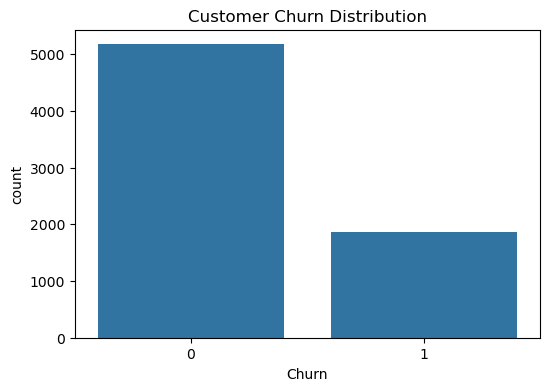

In [12]:
#  Churn Distribution
# ==========================
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

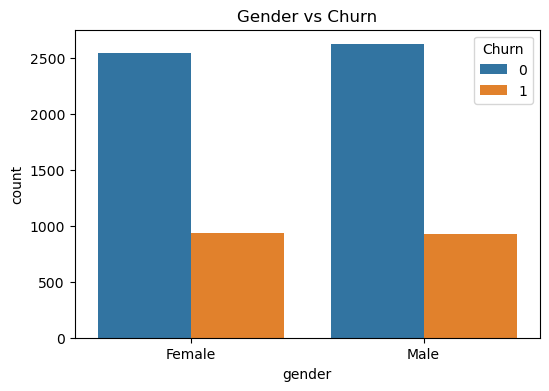

In [13]:
#  Gender vs Churn
# ==========================
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Gender vs Churn")
plt.show()

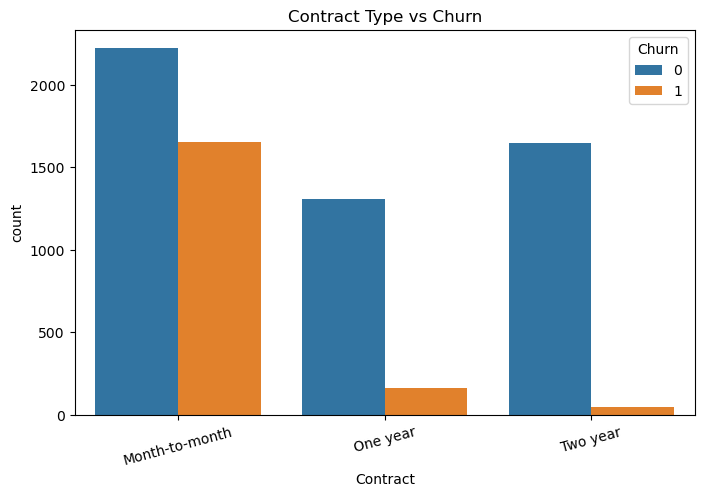

In [14]:
#  Contract Type vs Churn
# ==========================
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()


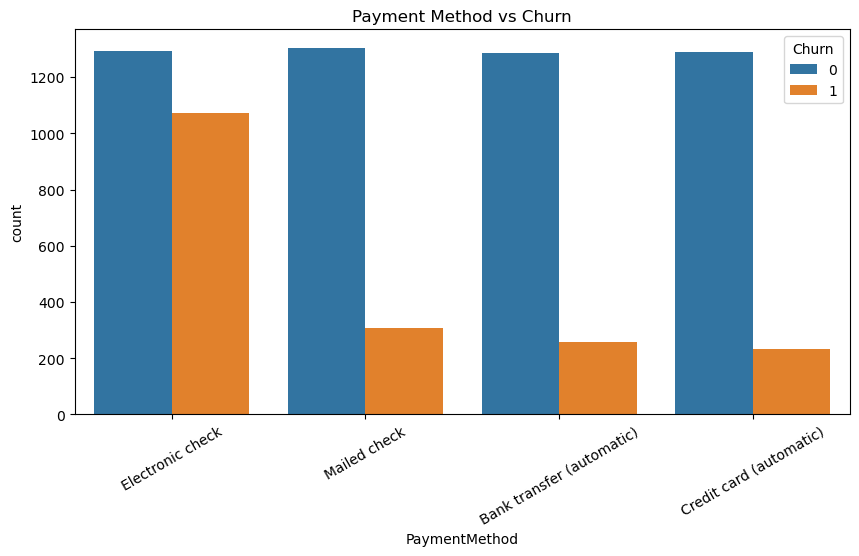

In [15]:
#  Payment Method vs Churn
# ==========================
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=30)
plt.show()

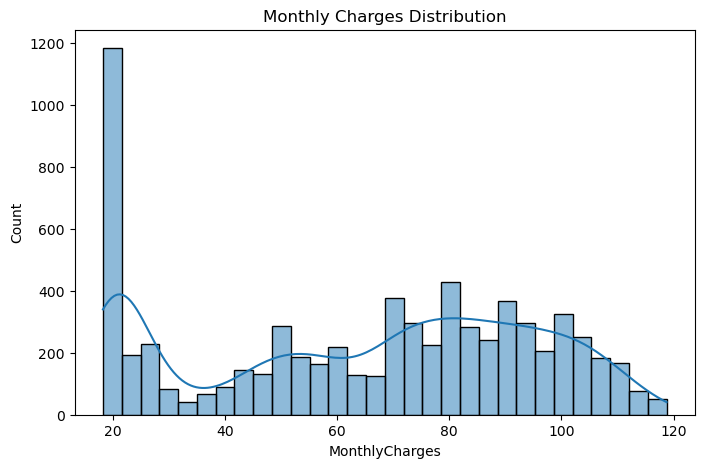

In [16]:
#  Monthly Charges Distribution
# ==========================
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

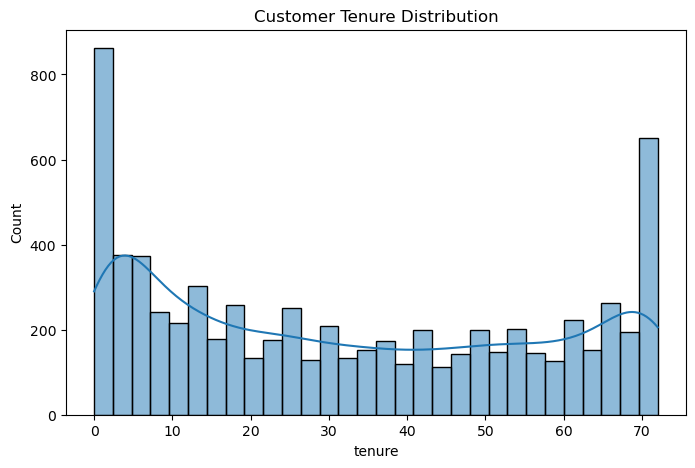

In [17]:
#  Tenure Distribution
# ==========================
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title("Customer Tenure Distribution")
plt.show()

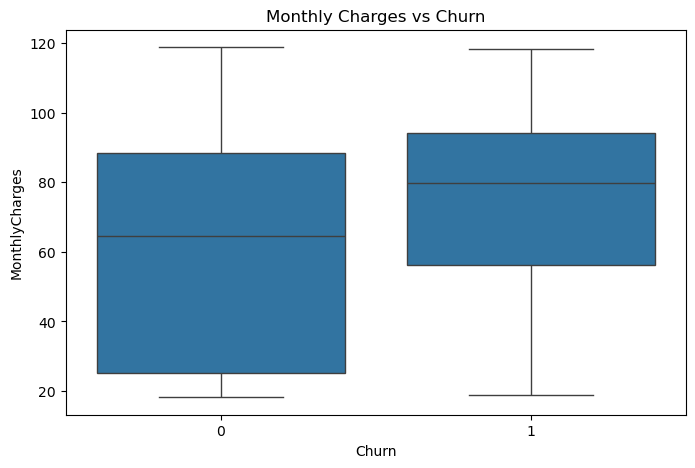

In [18]:
#  Churn vs Monthly Charges
# ==========================
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

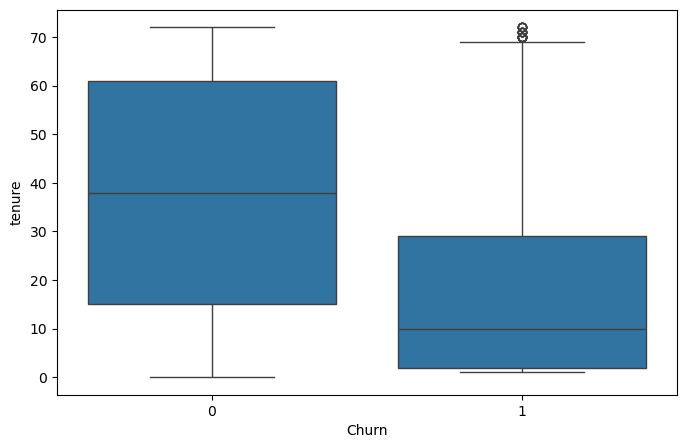

In [19]:
#  Churn vs tenure
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)
plt.show()

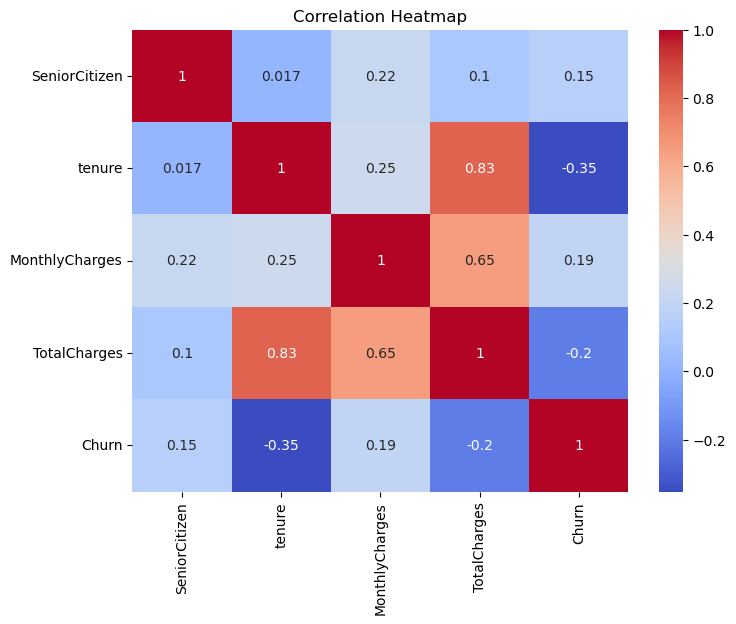

In [20]:
# 15. Correlation Heatmap
# ==========================
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [21]:
# 16. Churn Percentage
# ==========================
churn_rate = df['Churn'].mean() * 100
print(f"\nChurn Rate: {churn_rate:.2f}%")


Churn Rate: 26.54%


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


# Step 9: Feature Engineering

In [23]:
# ==========================

# Feature Engineering: Total Customer Spending

df['TotalSpend'] = df['MonthlyCharges'] * df['tenure']

df[['MonthlyCharges', 'tenure', 'TotalSpend']].head()

,MonthlyCharges,tenure,TotalSpend
0,29.85,1,29.85
1,56.95,34,1936.30
2,53.85,2,107.70
3,42.30,45,1903.50
4,70.70,2,141.40


In [24]:
#  Average Monthly Spending

df['AvgMonthlySpend'] = (
    df['TotalCharges'] /
    (df['tenure'] + 1)
)

df[['TotalCharges', 'tenure', 'AvgMonthlySpend']].head()

,TotalCharges,tenure,AvgMonthlySpend
0,29.85,1,14.925000
1,1889.50,34,53.985714
2,108.15,2,36.050000
3,1840.75,45,40.016304
4,151.65,2,50.550000


In [25]:
#  Contract Risk

df['ContractRisk'] = (
    df['Contract'] == 'Month-to-month'
).astype(int)

df[['Contract', 'ContractRisk']].head()

,Contract,ContractRisk
0,Month-to-month,1
1,One year,0
2,Month-to-month,1
3,One year,0
4,Month-to-month,1


In [26]:
#  Number of Services Used

df['ServiceCount'] = (
    (df['PhoneService'] == 'Yes').astype(int) +
    (df['OnlineSecurity'] == 'Yes').astype(int) +
    (df['OnlineBackup'] == 'Yes').astype(int) +
    (df['DeviceProtection'] == 'Yes').astype(int) +
    (df['TechSupport'] == 'Yes').astype(int) +
    (df['StreamingTV'] == 'Yes').astype(int) +
    (df['StreamingMovies'] == 'Yes').astype(int)
)

df[['ServiceCount']].head()

,ServiceCount
0,1
1,3
2,3
3,3
4,1


In [27]:
#  Cost Per Service

df['CostPerService'] = (
    df['MonthlyCharges'] /
    (df['ServiceCount'] + 1)
)

df[['MonthlyCharges', 'ServiceCount', 'CostPerService']].head()
# Purpose: Indicates perceived value for money.

,MonthlyCharges,ServiceCount,CostPerService
0,29.85,1,14.9250
1,56.95,3,14.2375
2,53.85,3,13.4625
3,42.30,3,10.5750
4,70.70,1,35.3500


In [28]:
#  Tenure Group

df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=[
        '0-1 Year',
        '1-2 Years',
        '2-4 Years',
        '4-6 Years'
    ]
)
# Purpose: Groups customers by subscription duration.

In [29]:
#  Monthly Charges Group

df['MonthlyChargesGroup'] = pd.qcut(
    df['MonthlyCharges'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)
# Purpose: Categorizes customers by spending level.

In [30]:
#  Senior Citizen + High Charges

median_charge = df['MonthlyCharges'].median()

df['SeniorHighCharge'] = (
    (df['SeniorCitizen'] == 1) &
    (df['MonthlyCharges'] > median_charge)
).astype(int)
# Purpose: Identifies potentially vulnerable high-cost customers.

In [31]:
#  Interaction Feature

df['Tenure_MonthlyCharges'] = (
    df['tenure'] *
    df['MonthlyCharges']
)
# Purpose: Captures the relationship between customer lifetime and spending.

In [32]:
new_features = [
    'TotalSpend',
    'AvgMonthlySpend',
    'ContractRisk',
    'ServiceCount',
    'CostPerService',
    'TenureGroup',
    'MonthlyChargesGroup',
    'SeniorHighCharge',
    'Tenure_MonthlyCharges'
]

print(df[new_features].head())

   TotalSpend  AvgMonthlySpend  ContractRisk  ServiceCount  CostPerService  \
0       29.85        14.925000             1             1         14.9250   
1     1936.30        53.985714             0             3         14.2375   
2      107.70        36.050000             1             3         13.4625   
3     1903.50        40.016304             0             3         10.5750   
4      141.40        50.550000             1             1         35.3500   

  TenureGroup MonthlyChargesGroup  SeniorHighCharge  Tenure_MonthlyCharges  
0    0-1 Year                 Low                 0                  29.85  
1   2-4 Years              Medium                 0                1936.30  
2    0-1 Year              Medium                 0                 107.70  
3   2-4 Years              Medium                 0                1903.50  
4    0-1 Year                High                 0                 141.40  


In [33]:
print(df.dtypes)

gender                     object
SeniorCitizen               int64
Partner                    object
Dependents                 object
tenure                      int64
PhoneService               object
MultipleLines              object
InternetService            object
OnlineSecurity             object
OnlineBackup               object
DeviceProtection           object
TechSupport                object
StreamingTV                object
StreamingMovies            object
Contract                   object
PaperlessBilling           object
PaymentMethod              object
MonthlyCharges            float64
TotalCharges              float64
Churn                       int64
TotalSpend                float64
AvgMonthlySpend           float64
ContractRisk                int32
ServiceCount                int32
CostPerService            float64
TenureGroup              category
MonthlyChargesGroup      category
SeniorHighCharge            int32
Tenure_MonthlyCharges     float64
dtype: object


In [34]:
categorical_cols = df.select_dtypes(
    include=['object', 'category']
).columns

print(categorical_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TenureGroup',
       'MonthlyChargesGroup'],
      dtype='object')


In [35]:
#  Customer Loyalty Score

df['LoyaltyScore'] = (
    df['tenure'] * df['ServiceCount']
)

# Step 10: Encoding & Preprocessing

In [36]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print(df_encoded.shape)

(7043, 45)


In [37]:
print(df.shape)
print(df_encoded.shape)

(7043, 30)
(7043, 45)


In [38]:
# Target variable
X = df_encoded.drop('Churn', axis=1)

y = df_encoded['Churn']

In [39]:
print(y.value_counts())
print(y.value_counts(normalize=True))

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


# Step 11: Train-Test Split

In [40]:
# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Step 12: Feature Scaling

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 13: Model 1 — Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score

lr_model = LogisticRegression(max_iter=10000)
lr_model.fit(X_train_scaled, y_train)   

# Step 5: Prediction
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# Step 6: Evaluation
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_lr))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))

print("Precision:", precision_score(y_test, y_test_pred_lr, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred_lr, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred_lr, average='weighted'))

cm = confusion_matrix(y_test, y_test_pred_lr)
print("Confusion Matrix:\n", cm)

Train Accuracy: 0.811324103656372
Test Accuracy: 0.801277501774308
Precision: 0.7912914191118993
Recall: 0.801277501774308
F1 Score: 0.7933181628246948
Confusion Matrix:
 [[934 101]
 [179 195]]


In [43]:
from sklearn.metrics import roc_auc_score

lr_prob = lr_model .predict_proba(X_test_scaled)[:,1]

auc = roc_auc_score(y_test, lr_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.8451161228654835


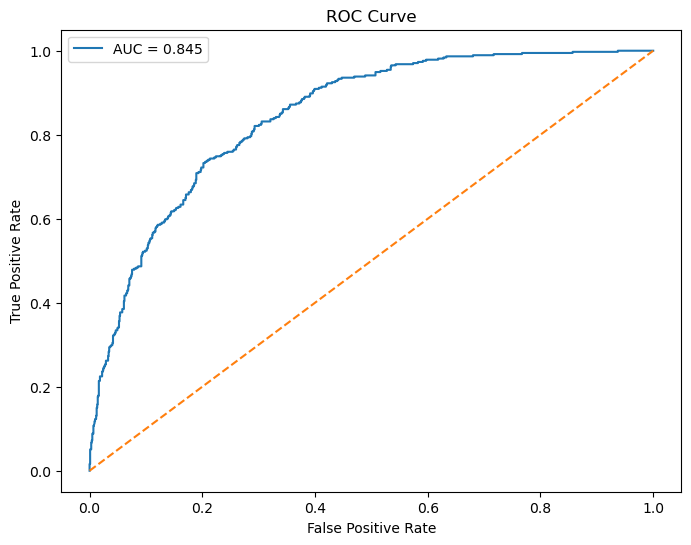

In [44]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, lr_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [45]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("ROC-AUC Scores:", scores.mean())
print("Average ROC-AUC:", scores.mean())

ROC-AUC Scores: 0.8482632174952791
Average ROC-AUC: 0.8482632174952791


# Step 14: Model 2 — Random Forest

In [46]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

rf_model.fit(X_train, y_train)

# Step 5: Prediction
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Step 6: Evaluation
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))

print("Precision:", precision_score(y_test, y_test_pred_rf, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred_rf, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred_rf, average='weighted'))

cm = confusion_matrix(y_test, y_test_pred_rf)
print("Confusion Matrix:\n", cm)

Train Accuracy: 0.8384806531771388
Test Accuracy: 0.8026969481902059
Precision: 0.7917676059266154
Recall: 0.8026969481902059
F1 Score: 0.7928029095237448
Confusion Matrix:
 [[943  92]
 [186 188]]


In [47]:
from sklearn.metrics import roc_auc_score

rf_prob = rf_model .predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, rf_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.846557648092175


# Step 14: Model 3 — XGBoost

In [48]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Step 5: Prediction
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Step 6: Evaluation
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_xgb))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_xgb))

print("Precision:", precision_score(y_test, y_test_pred_xgb, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred_xgb, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred_xgb, average='weighted'))

cm = confusion_matrix(y_test, y_test_pred_xgb)
print("Confusion Matrix:\n", cm)

Train Accuracy: 0.8248136315228967
Test Accuracy: 0.8019872249822569
Precision: 0.791146207323927
Recall: 0.8019872249822569
F1 Score: 0.7924431837560543
Confusion Matrix:
 [[941  94]
 [185 189]]


In [49]:
from sklearn.metrics import roc_auc_score

xgb_prob = xgb_model .predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, xgb_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.8484796817277636


# Step 15 : Model 4 — LightGBM

In [50]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

lgb_model = LGBMClassifier(
     n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, num_leaves=15, verbose=-1

)

lgb_model.fit(X_train, y_train)

# Step 5: Prediction
y_train_pred_lgb = lgb_model.predict(X_train)
y_test_pred_lgb = lgb_model.predict(X_test)

# Step 6: Evaluation
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_lgb))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_lgb))

print("Precision:", precision_score(y_test, y_test_pred_lgb, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred_lgb, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred_lgb, average='weighted'))

cm = confusion_matrix(y_test, y_test_pred_lgb)
print("Confusion Matrix:\n", cm)

Train Accuracy: 0.8262335818246361
Test Accuracy: 0.7991483321504613
Precision: 0.7895843037498596
Recall: 0.7991483321504613
F1 Score: 0.7919465573606771
Confusion Matrix:
 [[929 106]
 [177 197]]


In [51]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lgb_model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print("ROC-AUC Scores:", scores)
print("Average ROC-AUC:", scores.mean())

ROC-AUC Scores: [0.854787   0.85628924 0.83083779 0.8402896  0.845009  ]
Average ROC-AUC: 0.8454425240111985


In [52]:
from sklearn.metrics import roc_auc_score

lgb_prob = lgb_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, lgb_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8444211940375623


# Step 16: Model 5 — CatBoost

In [53]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.01,
    depth=6,
    random_state=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

# Step 5: Prediction
y_train_pred_cat = cat_model.predict(X_train)
y_test_pred_cat = cat_model.predict(X_test)

# Step 6: Evaluation
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_cat))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_cat))

print("Precision:", precision_score(y_test, y_test_pred_cat, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred_cat, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred_cat, average='weighted'))

cm = confusion_matrix(y_test, y_test_pred_cat)
print("Confusion Matrix:\n", cm)

Train Accuracy: 0.8157614483493077
Test Accuracy: 0.8026969481902059
Precision: 0.7915576519309202
Recall: 0.8026969481902059
F1 Score: 0.7922826737084316
Confusion Matrix:
 [[945  90]
 [188 186]]


In [54]:
from sklearn.metrics import roc_auc_score

cat_prob = cat_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, cat_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8469219044666616


In [55]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    cat_model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print("Average ROC-AUC:", scores.mean())

Average ROC-AUC: 0.8472439128547455


# Feature Importance — CatBoost

In [56]:
feature_names = X.columns

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': cat_model.feature_importances_
})

print(
    feature_importance.sort_values(
        by='Importance',
        ascending=False
    ).head(10)
)

                           Feature  Importance
6                     ContractRisk   16.739255
1                           tenure   10.081391
8                   CostPerService    9.152188
18     InternetService_Fiber optic    5.645385
2                   MonthlyCharges    4.935348
33               Contract_Two year    4.923653
36  PaymentMethod_Electronic check    4.850387
10           Tenure_MonthlyCharges    4.292285
34            PaperlessBilling_Yes    4.134760
5                  AvgMonthlySpend    3.422590


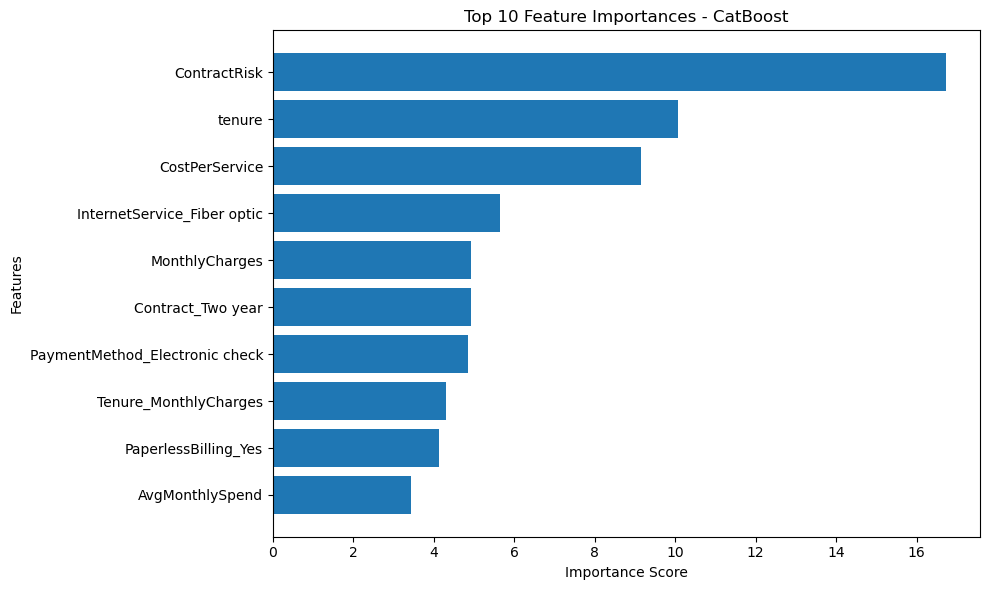

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace X.columns with your actual feature names
feature_names = X.columns

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': cat_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Top 10 Features
top_features = feature_importance.head(10)

# Plot
plt.figure(figsize=(10,6))
plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Feature Importances - CatBoost')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Model Explainability using SHAP

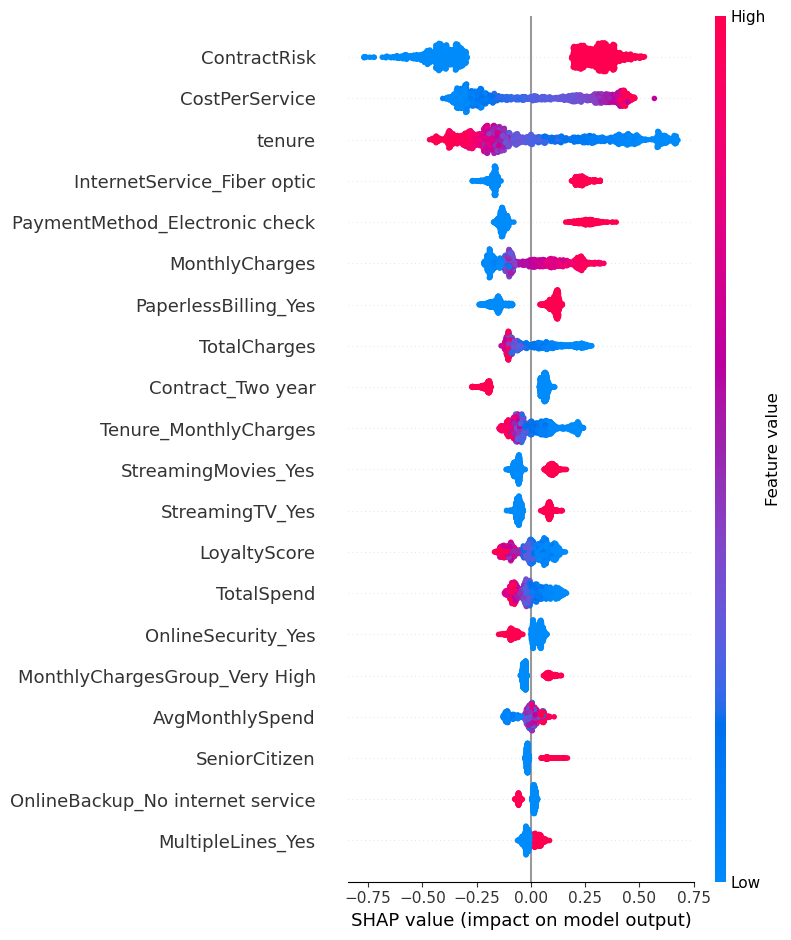

In [58]:
import shap

# Create SHAP Explainer
explainer = shap.TreeExplainer(cat_model)

# Calculate SHAP Values
shap_values = explainer.shap_values(X_test)

# Summary Plot
shap.summary_plot(
    shap_values,
    X_test
)

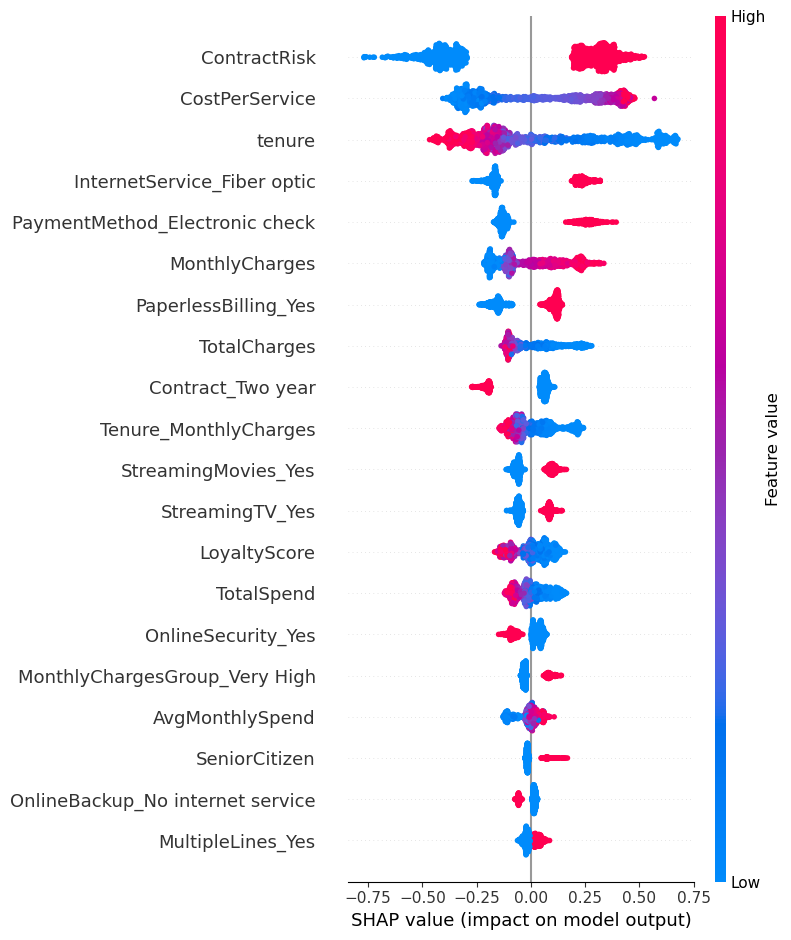

In [59]:
X_test_df = pd.DataFrame(
    X_test,
    columns=X.columns
)

shap.summary_plot(
    shap_values,
    X_test_df
)

# Collect All Metrics into a DataFrame

In [60]:

def get_metrics(name, y_true, y_pred, y_prob):
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1 Score':  f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'ROC-AUC':   roc_auc_score(y_true, y_prob)
    }
 
results = [
    get_metrics('Logistic Regression', y_test, y_test_pred_lr,  lr_prob),
    get_metrics('Random Forest',        y_test, y_test_pred_rf,  rf_model.predict_proba(X_test)[:, 1]),
    get_metrics('XGBoost',              y_test, y_test_pred_xgb, xgb_prob),
    get_metrics('LightGBM',             y_test, y_test_pred_lgb, lgb_prob),
    get_metrics('CatBoost',             y_test, y_test_pred_cat, cat_prob),
]
 
comparison_df = pd.DataFrame(results).set_index('Model')
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)
 
print("=" * 65)
print("            MODEL COMPARISON SUMMARY")
print("=" * 65)
print(comparison_df.round(4).to_string())
print("=" * 65)
print(f"\n🏆 Best Model by ROC-AUC : {comparison_df['ROC-AUC'].idxmax()}")
print(f"🏆 Best Model by F1 Score: {comparison_df['F1 Score'].idxmax()}")
print(f"🏆 Best Model by Accuracy: {comparison_df['Accuracy'].idxmax()}")

            MODEL COMPARISON SUMMARY
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
XGBoost                0.8020     0.7911  0.8020    0.7924   0.8485
CatBoost               0.8027     0.7916  0.8027    0.7923   0.8469
Random Forest          0.8027     0.7918  0.8027    0.7928   0.8466
Logistic Regression    0.8013     0.7913  0.8013    0.7933   0.8451
LightGBM               0.7991     0.7896  0.7991    0.7919   0.8444

🏆 Best Model by ROC-AUC : XGBoost
🏆 Best Model by F1 Score: Logistic Regression
🏆 Best Model by Accuracy: CatBoost


# Bar Chart — All Metrics Side-by-Side

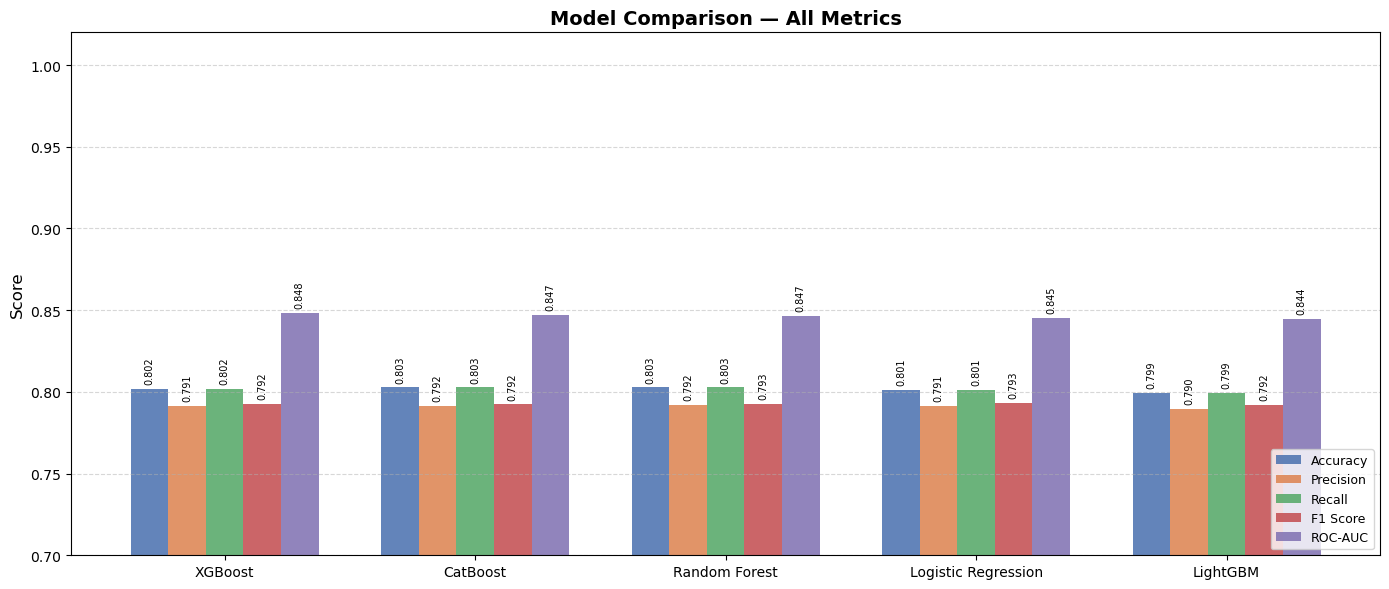

In [61]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(comparison_df))
width = 0.15
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
 
fig, ax = plt.subplots(figsize=(14, 6))
 
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, comparison_df[metric], width, label=metric, color=color, alpha=0.87)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=7, rotation=90
        )
 
ax.set_xticks(x + width * 2)
ax.set_xticklabels(comparison_df.index, fontsize=10)
ax.set_ylim(0.70, 1.02)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Heatmap — Metric Scores per Model

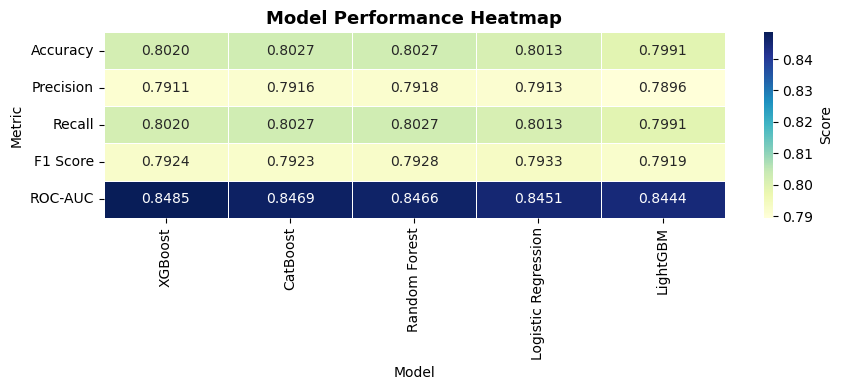

In [62]:

plt.figure(figsize=(9, 4))
sns.heatmap(
    comparison_df[metrics].T,
    annot=True, fmt='.4f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Score'}
)
plt.title('Model Performance Heatmap', fontsize=13, fontweight='bold')
plt.ylabel('Metric')
plt.xlabel('Model')
plt.tight_layout()
plt.show()

# ROC Curves — All Models Overlaid

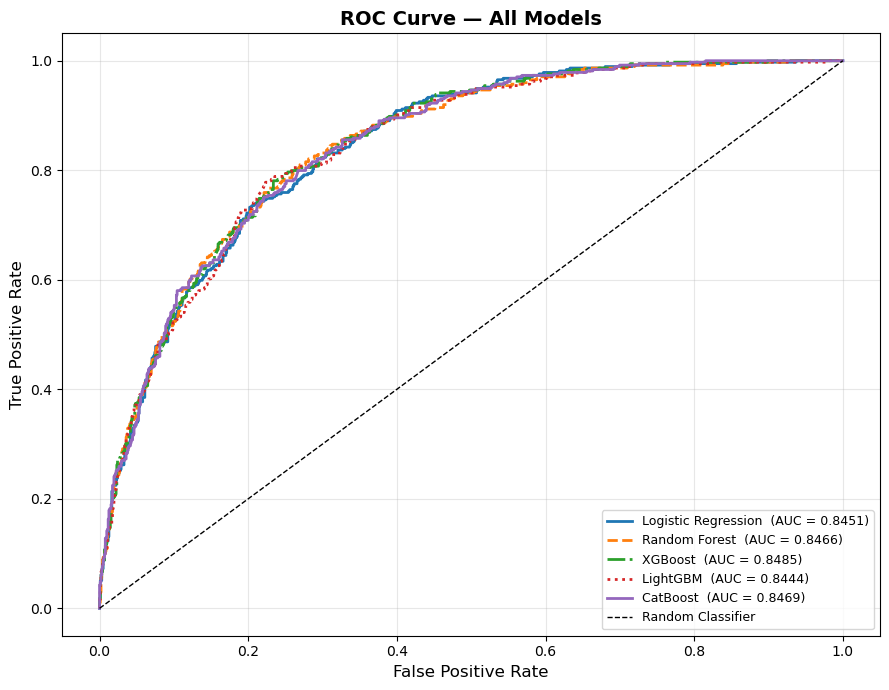

In [63]:

model_probs = {
    'Logistic Regression': lr_prob,
    'Random Forest':        rf_model.predict_proba(X_test)[:, 1],
    'XGBoost':              xgb_prob,
    'LightGBM':             lgb_prob,
    'CatBoost':             cat_prob,
}
 
line_styles = ['-', '--', '-.', ':', '-']
plt.figure(figsize=(9, 7))
 
for (name, prob), ls in zip(model_probs.items(), line_styles):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, linestyle=ls, linewidth=2, label=f'{name}  (AUC = {auc:.4f})')
 
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()

# Confusion Matrices — All Models (Grid)

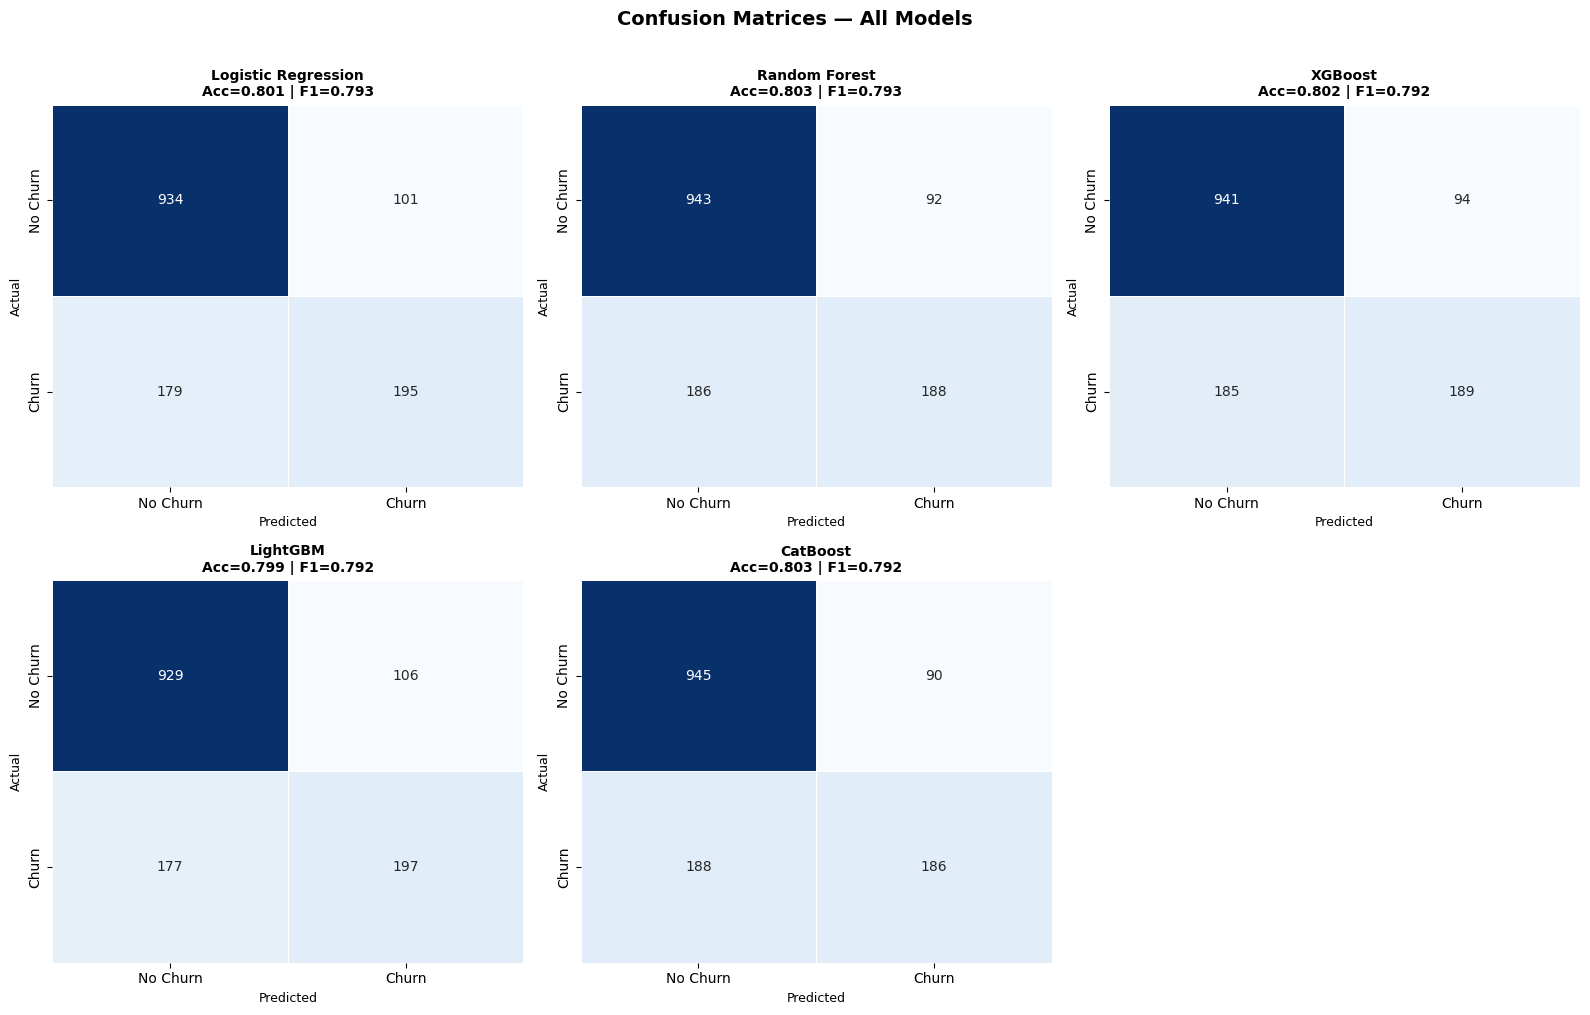

In [64]:

model_preds = {
    'Logistic Regression': y_test_pred_lr,
    'Random Forest':        y_test_pred_rf,
    'XGBoost':              y_test_pred_xgb,
    'LightGBM':             y_test_pred_lgb,
    'CatBoost':             y_test_pred_cat,
}
 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
 
for ax, (name, y_pred) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn'],
        linewidths=0.5, cbar=False
    )
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    ax.set_title(f'{name}\nAcc={acc:.3f} | F1={f1:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
 
# Hide the unused 6th subplot
axes[-1].set_visible(False)
 
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Overfitting Check — Train vs Test Accuracy

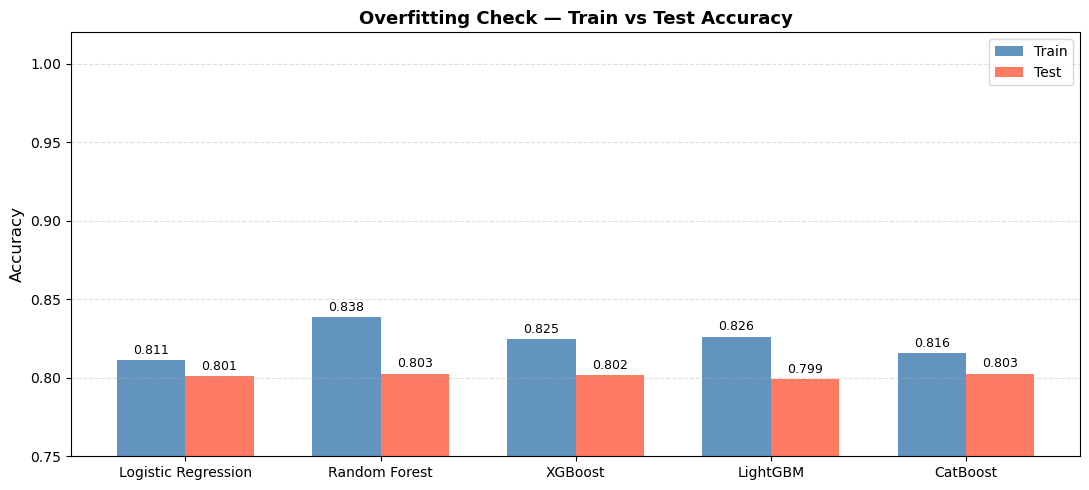


Overfitting Check:
                     Train Accuracy  Test Accuracy
Model                                             
Logistic Regression          0.8113         0.8013
Random Forest                0.8385         0.8027
XGBoost                      0.8248         0.8020
LightGBM                     0.8262         0.7991
CatBoost                     0.8158         0.8027


In [65]:

train_preds = {
    'Logistic Regression': y_train_pred_lr,
    'Random Forest':        y_train_pred_rf,
    'XGBoost':              y_train_pred_xgb,
    'LightGBM':             y_train_pred_lgb,
    'CatBoost':             y_train_pred_cat,
}
 
overfit_data = []
for name in model_preds:
    train_acc = accuracy_score(y_train, train_preds[name])
    test_acc  = accuracy_score(y_test,  model_preds[name])
    overfit_data.append({'Model': name, 'Train Accuracy': train_acc, 'Test Accuracy': test_acc})
 
overfit_df = pd.DataFrame(overfit_data).set_index('Model')
 
x = np.arange(len(overfit_df))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, overfit_df['Train Accuracy'], w, label='Train', color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, overfit_df['Test Accuracy'],  w, label='Test',  color='tomato',    alpha=0.85)
 
for bars in [b1, b2]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9
        )
 
ax.set_xticks(x)
ax.set_xticklabels(overfit_df.index, fontsize=10)
ax.set_ylim(0.75, 1.02)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Overfitting Check — Train vs Test Accuracy', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
 
print("\nOverfitting Check:")
print(overfit_df.round(4).to_string())

# SAVE MODELS AS PICKLE FILES

In [66]:
import pickle

# Define feature columns
feature_columns = list(X.columns)

# Save Models
pickle.dump(lr_model,  open("lr_model.pkl",  "wb"))
pickle.dump(rf_model,  open("rf_model.pkl",  "wb"))
pickle.dump(xgb_model, open("xgb_model.pkl", "wb"))
pickle.dump(lgb_model, open("lgb_model.pkl", "wb"))
pickle.dump(cat_model, open("cat_model.pkl", "wb"))

# Save Scaler & Feature Columns
pickle.dump(scaler,          open("scaler.pkl",          "wb"))
pickle.dump(feature_columns, open("feature_columns.pkl", "wb"))

print("✅ All models saved successfully!")

# Show where files are saved
import os
print("\n📁 Saved in:", os.getcwd())
print("\n📄 Files created:")
for f in os.listdir('.'):
    if f.endswith('.pkl'):
        print(f"   ✅ {f}")


✅ All models saved successfully!

📁 Saved in: C:\Users\Alokp\alok-project

📄 Files created:
   ✅ cat_model.pkl
   ✅ feature_columns.pkl
   ✅ lgb_model.pkl
   ✅ lr_model.pkl
   ✅ rf_model.pkl
   ✅ scaler.pkl
   ✅ xgb_model.pkl
